In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import linregress

import global_biomass as gb

In [2]:
#set global font size
plt.rcParams.update({'font.size': 16})

In [3]:
df_2015_CCI = pd.read_csv("Haldwani_2015_CCI.csv")
df_2017_CCI = pd.read_csv("Haldwani_2017_CCI.csv")
df_2018_CCI = pd.read_csv("Haldwani_2018_CCI.csv")
df_2023_CCI = pd.read_csv("Haldwani_2023_CCI_2022.csv")


df_2018_GEDI = pd.read_csv("Haldwani_2018_GEDI.csv")
df_2023_GEDI = pd.read_csv("Haldwani_2023_GEDI.csv")

df_2023_GFW_AGB = pd.read_csv("Haldwani_2023_GFW_AGB_2022.csv")
df_2023_GFW_SD = pd.read_csv("Haldwani_2023_GFW_SD_2022.csv")


In [4]:
cci_data = {
    2015: pd.read_csv("Haldwani_2015_CCI.csv"),
    2017: pd.read_csv("Haldwani_2017_CCI.csv"),
    2018: pd.read_csv("Haldwani_2018_CCI.csv"),
    2023: pd.read_csv("Haldwani_2023_CCI_2022.csv")
}

gedi_data = {
    2018: pd.read_csv("Haldwani_2018_GEDI.csv"),
    2023: pd.read_csv("Haldwani_2023_GEDI.csv")
}

gfw_agb = pd.read_csv("Haldwani_2023_GFW_AGB_2022.csv")
gfw_sd  = pd.read_csv("Haldwani_2023_GFW_SD_2022.csv")

In [5]:
for yr, df in gedi_data.items():

    print(f"\n{yr}")

    print(
        df[
            ["AGB","GEDI_1","GEDI_2"]
        ].isna().sum()
    )


2018
AGB        0
GEDI_1    20
GEDI_2    20
dtype: int64

2023
AGB       0
GEDI_1    9
GEDI_2    9
dtype: int64


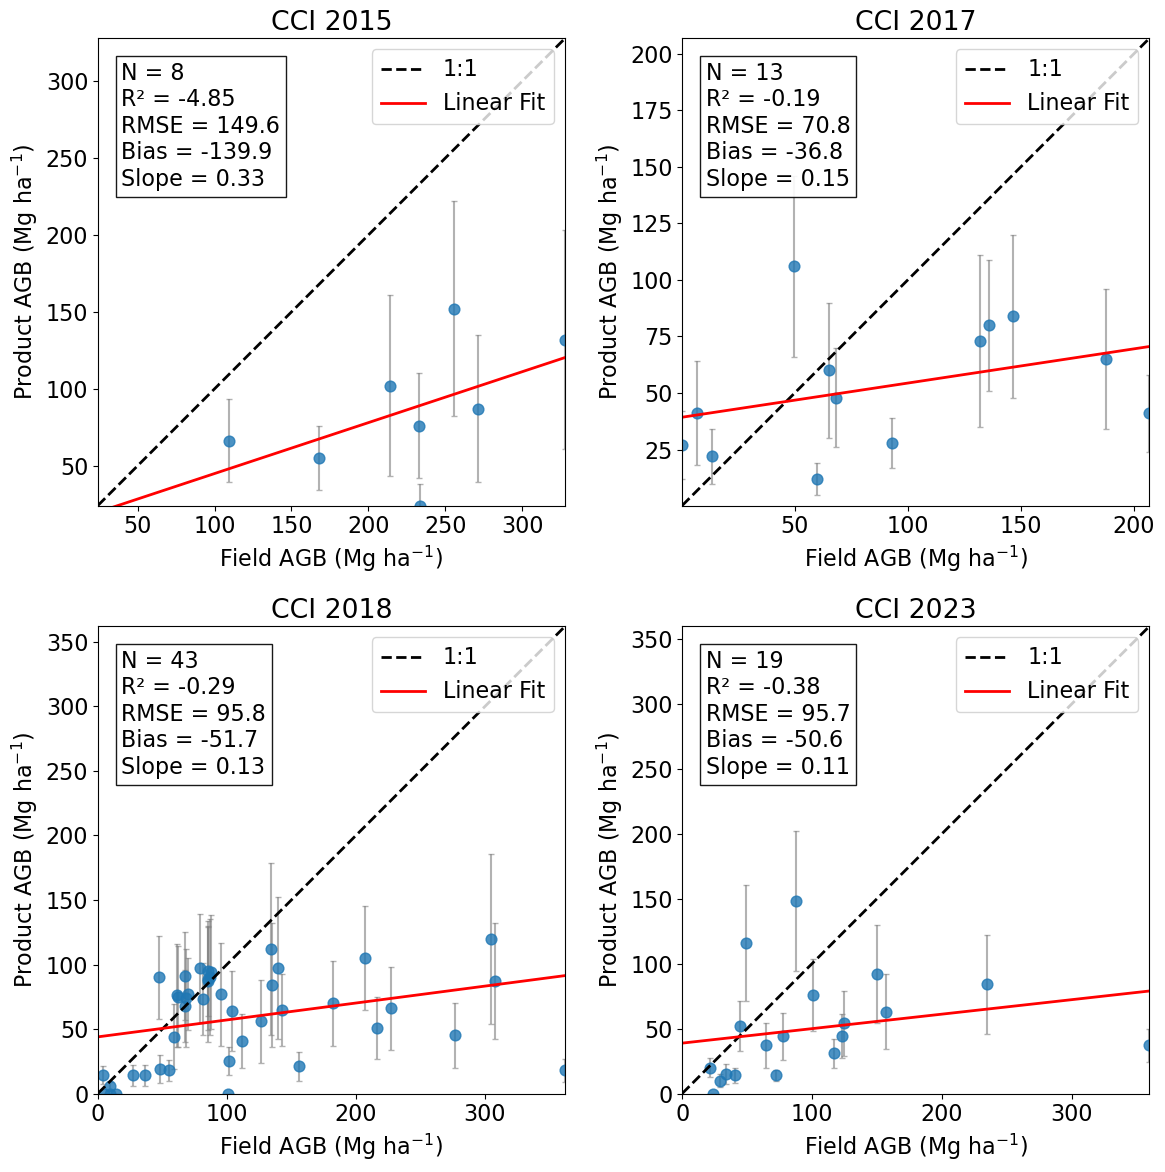

In [6]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,12)
)

axes = axes.flatten()

for ax, (yr, df) in zip(
    axes,
    cci_data.items()
):

    gb.biomass_scatter(
        ax=ax,
        df=df,
        field_col="AGB",
        pred_col="CCI_1",
        sd_col="CCI_2",
        title=f"CCI {yr}"
    )

plt.tight_layout()
plt.show()

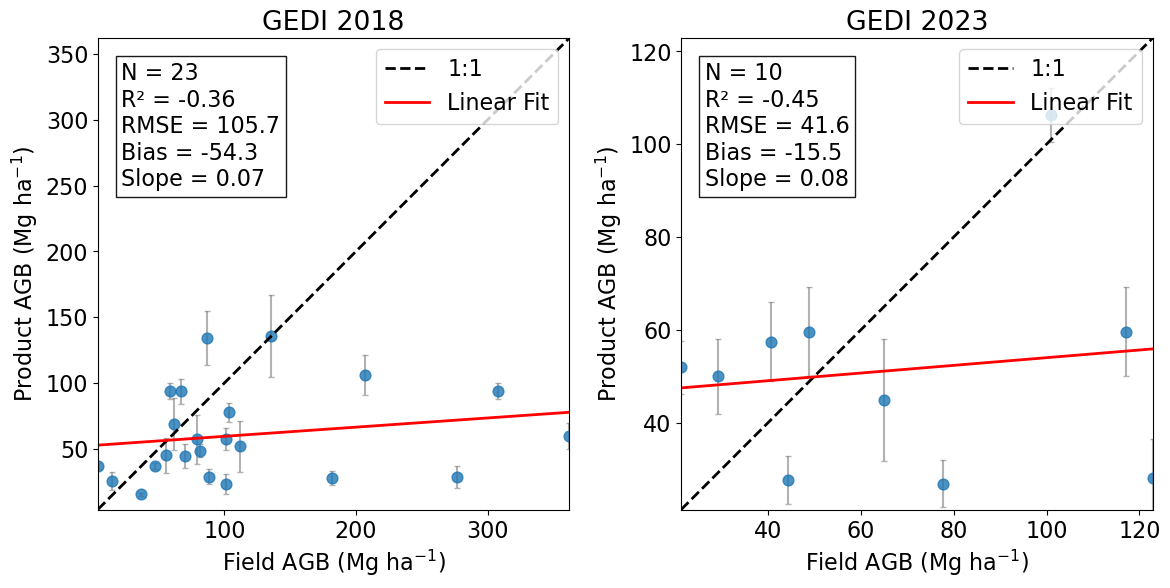

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

for ax, (yr, df) in zip(
    axes,
    gedi_data.items()
):

    gb.biomass_scatter(
        ax=ax,
        df=df,
        field_col="AGB",
        pred_col="GEDI_1",
        sd_col="GEDI_2",
        title=f"GEDI {yr}"
    )

plt.tight_layout()
plt.show()

In [8]:
df_2023_GFW_AGB.columns

Index(['h100', 'Year', 'AGB', 'GFW_AGB1'], dtype='str')

In [9]:
df_2023_GFW_SD.columns

Index(['h100', 'Year', 'AGB', 'GFW_SD1'], dtype='str')

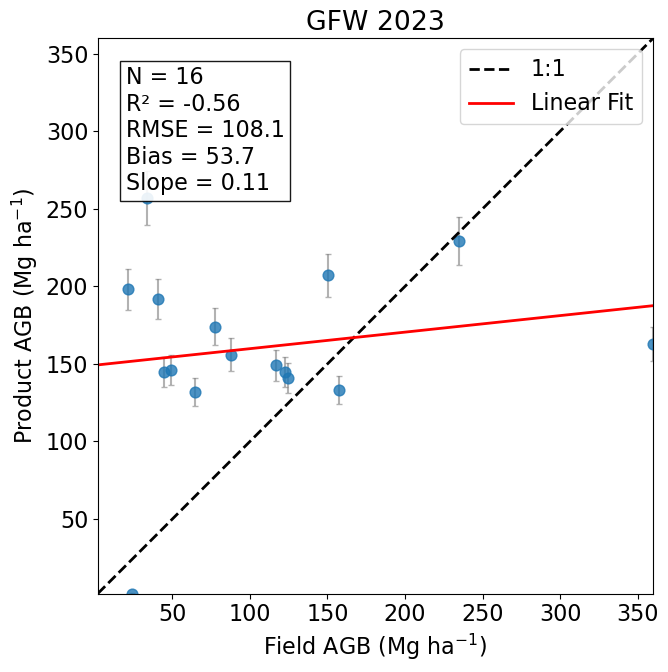

In [10]:
gfw_df = pd.DataFrame({
    "AGB": df_2023_GFW_AGB["AGB"],
    "GFW_AGB": df_2023_GFW_AGB["GFW_AGB1"],
    "GFW_SD": df_2023_GFW_SD["GFW_SD1"]
})

fig, ax = plt.subplots(
    figsize=(7,7)
)

gb.biomass_scatter(
    ax=ax,
    df=gfw_df,
    field_col="AGB",
    pred_col="GFW_AGB",
    sd_col="GFW_SD",
    title="GFW 2023"
)

plt.tight_layout()
plt.show()